# Time-Series Forecasting of Carbon Monoxide and Nitrogen Dioxide Levels

Build predictive models to forecast daily or hourly concentrations of **CO(GT)** and **NO₂(GT)** based on historical data.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import numpy as np

warnings.filterwarnings('ignore')

In [2]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/airquality.csv'
df = pd.read_csv(url)
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [3]:
df.columns

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='str')

# Project Workflow

### **Deliverables**:
1. **Forecasting Models**:
   - Trained models for `CO(GT)` and `NO₂(GT)`.
2. **Forecast Visualization**:
   - Plots showing historical trends and future predictions.
3. **Evaluation Report**:
   - Metrics and comparison of different forecasting models.
4. **Insights and Recommendations**:
   - Suggestions for mitigating high levels of these gases based on predictions.


### 1. Data Preprocessing
- **Date-Time Parsing**:
  - Combine the `Date` and `Time` columns into a single `datetime` column.
  - Set the `datetime` column as the index of the dataset.
- **Resampling**:
  - Aggregate the data into meaningful time intervals (e.g., hourly or daily averages).
- **Handle Missing Values**:
  - Use interpolation, mean, or advanced imputation techniques to fill missing data for `CO(GT)` and `NO₂(GT)`.
- **Outlier Detection**:
  - Remove or cap extreme values in `CO(GT)` and `NO₂(GT)` using statistical thresholds.

In [4]:
# copy dataframe for date and time concatenation 
df_dt = df.copy()

In [5]:
df_dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), str(2)
memory usage: 1.1 MB


In [6]:
# Adding Date and time 
df_dt['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'])
df_dt.set_index('datetime', inplace=True)
df_dt.index = pd.to_datetime(df_dt.index)
df_dt.index.name = 'datetime'

# Drop date and time columns
df_dt.drop(['Date', 'Time'], axis=1, inplace=True)
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [7]:
def aggregation(col_name):
    return df_dt[col_name].resample('d').mean()

print(aggregation('CO(GT)'))
print(aggregation('NO2(GT)'))

datetime
2004-03-10     1.966667
2004-03-11    -6.187500
2004-03-12   -14.095833
2004-03-13    -5.750000
2004-03-14    -5.966667
                ...    
2005-03-31     1.387500
2005-04-01    -7.270833
2005-04-02     0.854167
2005-04-03     1.141667
2005-04-04   -11.393333
Freq: D, Name: CO(GT), Length: 391, dtype: float64
datetime
2004-03-10    108.833333
2004-03-11     87.375000
2004-03-12     89.916667
2004-03-13    105.583333
2004-03-14     97.458333
                 ...    
2005-03-31    100.708333
2005-04-01    107.333333
2005-04-02    100.166667
2005-04-03    111.125000
2005-04-04    122.000000
Freq: D, Name: NO2(GT), Length: 391, dtype: float64


In [8]:
print(f'CO variable type : {df_dt['CO(GT)'].dtype}')
print(f'NO2 variable type : {df_dt['NO2(GT)'].dtype}')
print(f'T variable type : {df_dt['T'].dtype}')

CO variable type : float64
NO2 variable type : int64
T variable type : float64


In [9]:
def set_null():
    for i in df_dt.columns:
        df_dt[i] = df_dt[i].mask(df_dt[i] == -200, np.nan)

set_null()
df_dt.to_csv("airquality_replace_missing_value_66.csv")

In [10]:
# count total missing values
# count cosecutive missing values
def count_missing_val(col_name_cosec):
    is_na = df_dt[col_name_cosec].isna()
    max_strek = 0
    current_strek = 0

    for i in is_na:
        if i == True:
            current_strek += 1
            if current_strek > max_strek:
                max_strek = current_strek
        else:
            current_strek = 0

    return print(f'Total missing values (nan) of {col_name_cosec} : {df_dt[col_name_cosec].isna().sum()}\nMaximum Consecutive Missing for {col_name_cosec}: {max_strek}')

In [11]:
count_missing_val('CO(GT)')

Total missing values (nan) of CO(GT) : 1683
Maximum Consecutive Missing for CO(GT): 173


In [12]:
count_missing_val('NO2(GT)')

Total missing values (nan) of NO2(GT) : 1642
Maximum Consecutive Missing for NO2(GT): 173


In [13]:
# function for detecting gap of consecutive missing values
def measure_missing_val_gap(col_name_gap, consec_missing_val):
    is_na = df_dt[col_name_gap].isna()
    start = None
    count = 0
    for idx, val in is_na.items():
        if val:
            if start is None:
                start = idx
            count += 1
        else:
            if count == consec_missing_val:
                return print(f'{col_name_gap} - Gap Start : {start}\n{col_name_gap} - Gap End : {prev_idx}')
            start = None
            count = 0

        prev_idx = idx


measure_missing_val_gap('CO(GT)', 173)
print('-----------------------------------------')
measure_missing_val_gap('NO2(GT)', 173)


CO(GT) - Gap Start : 2004-10-13 11:00:00
CO(GT) - Gap End : 2004-10-20 15:00:00
-----------------------------------------
NO2(GT) - Gap Start : 2004-10-13 11:00:00
NO2(GT) - Gap End : 2004-10-20 15:00:00


In [14]:
# function for deleting consecutive missing values
def delete_consecutive_missing_val(col_name, df, threshold):

    is_missing = df[col_name].isna()

    current_streak = 0
    gap_start = None
    drop_index_list = []

    for t, miss in is_missing.items():
        if miss:
            if current_streak == 0:
                gap_start = t
            current_streak += 1
            gap_end = t
        else:
            if current_streak > threshold:
                drop_index_list.extend(df.loc[gap_start:gap_end].index)
            current_streak = 0
            gap_start = None

    if current_streak > threshold:
        drop_index_list.extend(df.loc[gap_start:gap_end].index)

    dropped = len(drop_index_list)
    df_new = df.drop(drop_index_list)

    print(f'{col_name} Consecutive Missing values - Dropped rows : {dropped}')
    return df_new

df_dt = delete_consecutive_missing_val('CO(GT)', df_dt, 24)
df_dt = delete_consecutive_missing_val('NO2(GT)', df_dt, 24)

CO(GT) Consecutive Missing values - Dropped rows : 1357
NO2(GT) Consecutive Missing values - Dropped rows : 148


In [15]:
# replace missing values of all features by Time Interpolation
def set_time_interpolate():
    for i in df_dt.columns:
        df_dt[i] = df_dt[i].interpolate(method='time')

set_time_interpolate()
df_dt.to_csv('airquality_test_1099.csv')

In [16]:
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [17]:
# Remove extreme values (Outlier)
def outlier_removal(col_name):
    outlier = []
    key_outlier = []
    global df_dt

    q1 = np.percentile(df_dt[col_name], 25)
    q3 = np.percentile(df_dt[col_name], 75)

    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    for key, i in enumerate (df_dt[col_name]):
        if i < lower_bound or i > upper_bound :
            outlier.append(i)
            key_outlier.append(key)

    print(f'Outliers : {outlier}')
    print(f'Outliers key : {key_outlier}')
    df_dt = df_dt.drop(df_dt.index[key_outlier])


In [18]:
for i in range(4):
    outlier_removal('CO(GT)')
    outlier_removal('NO2(GT)')

Outliers : [6.9, 6.1, 6.6, 5.9, 8.1, 5.8, 6.1, 8.0, 6.5, 6.6, 7.6, 6.7, 6.6, 6.2, 6.2, 6.2, 6.3, 5.9, 7.3, 6.1, 6.4, 6.0, 7.2, 6.5, 6.3, 5.9, 6.5, 6.2, 5.8, 6.4, 6.2, 6.1, 6.7, 6.5, 7.3, 6.7, 7.5, 6.3, 6.5, 6.3, 6.7, 7.0, 8.0, 7.7, 6.8, 6.0, 6.0, 8.4, 6.8, 7.9, 8.4, 8.0, 6.4, 5.8, 8.4, 9.5, 6.2, 6.5, 5.9, 6.6, 5.8, 7.5, 5.8, 5.9, 6.8, 7.9, 8.0, 9.2, 5.9, 5.866666666666667, 6.433333333333334, 7.0, 7.566666666666666, 8.133333333333333, 8.7, 5.8, 6.2, 8.1, 8.0, 5.9, 6.8, 7.8, 10.2, 6.6, 5.9, 7.5, 7.2, 8.3, 8.6, 6.3, 6.9, 6.5, 6.6, 7.3, 7.3, 10.2, 11.9, 11.5, 8.3, 6.1, 6.8, 8.4, 5.8, 6.2, 7.7, 10.1, 6.4, 7.7, 8.1, 5.9, 6.3, 6.6, 6.3, 6.8, 6.2, 7.5, 7.7, 9.4, 7.8, 6.6, 6.0, 6.9, 6.1, 6.2, 6.3, 5.9, 9.9, 6.9, 7.4, 9.3, 7.4, 6.6, 7.3, 7.5, 8.6, 9.1, 8.6, 6.3, 6.6, 8.5, 8.7, 9.1, 7.2, 6.1, 6.6, 6.5, 6.0, 6.9, 7.9, 6.1, 6.7, 6.8, 6.7, 6.4, 6.8, 5.9, 6.2, 5.9, 5.9, 5.9, 5.8, 5.8, 8.6, 8.7, 5.8, 6.0, 6.4, 6.1, 6.8, 6.8, 6.7, 5.8, 5.9, 6.7, 6.4, 6.2, 8.4, 5.9, 5.8, 6.1, 7.1, 6.6, 6.5, 7.1, 6.3, 5.

### 2. Exploratory Data Analysis (EDA)
- **Trend Analysis**:
  - Visualize the long-term trends of `CO(GT)` and `NO₂(GT)`.
- **Seasonality**:
  - Identify seasonal patterns (e.g., daily or yearly fluctuations).
- **Correlation Analysis**:
  - Explore relationships between `CO(GT)`, `NO₂(GT)`, and other features (e.g., temperature or humidity).


The NO₂(GT) time series shows a clear upward trend over time, indicating a gradual increase in pollution levels. In contrast, CO(GT) does not exhibit a strong long-term trend but shows significant short-term fluctuations, suggesting variability without consistent growth.

Trend Analysis

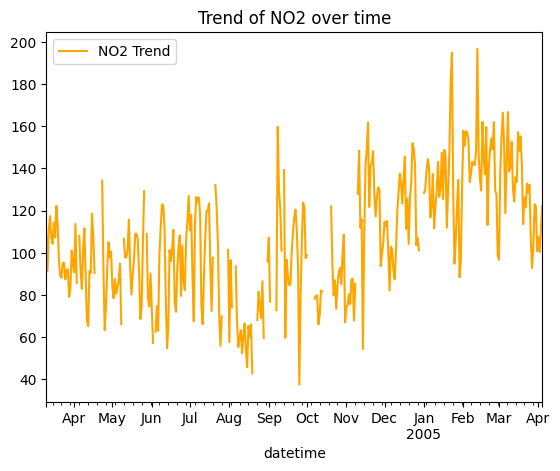

In [19]:
# Trend Analysis
# df_dt['CO(GT)'].rolling(window=24).mean().plot(label='CO Trend')
df_dt['NO2(GT)'].resample('D').mean().plot(label='NO2 Trend', color='orange')
plt.legend()
plt.title('Trend of NO2 over time')
plt.show()

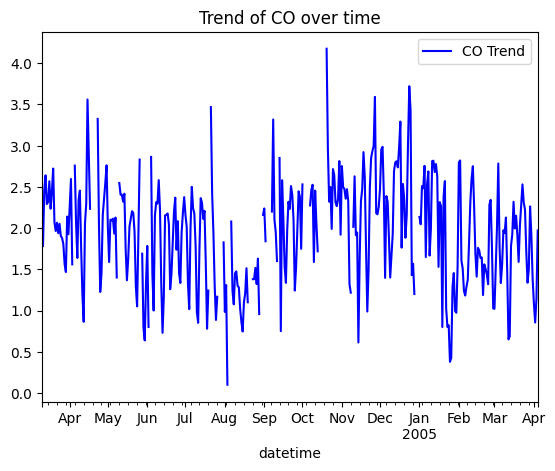

In [20]:
df_dt['CO(GT)'].resample('D').mean().plot(label='CO Trend', color='blue')
plt.legend()
plt.title('Trend of CO over time')
plt.show()

Seasonality Test

<Axes: xlabel='datetime'>

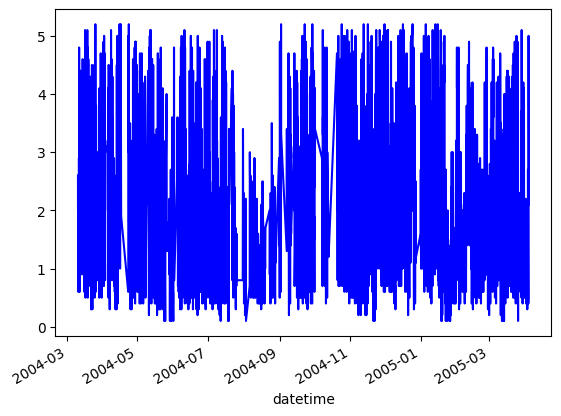

In [21]:
df_dt['CO(GT)'].plot(label='CO Seasonality Trend', color='blue')

<Axes: xlabel='datetime'>

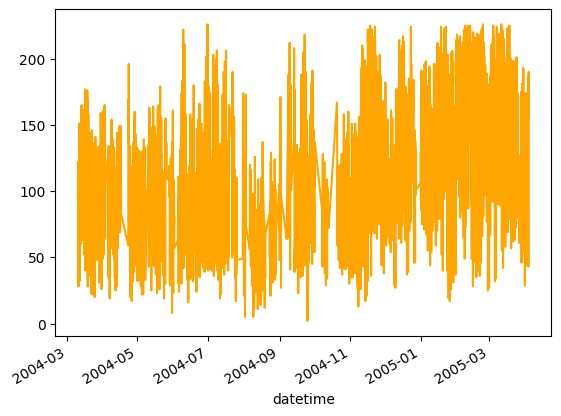

In [22]:
df_dt['NO2(GT)'].plot(label='NO2 Seasonality Trend', color='orange')

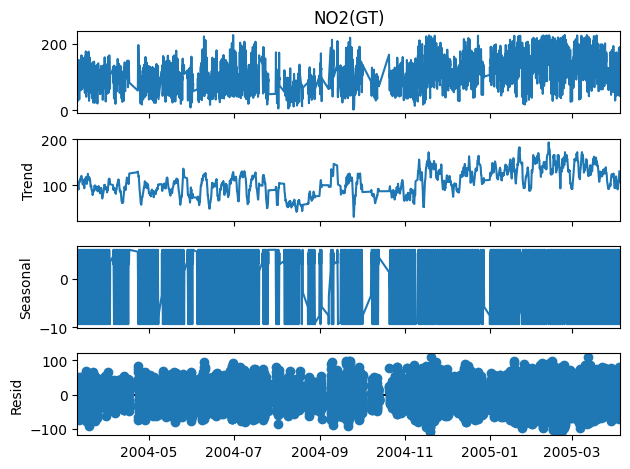

In [23]:
# seasonal decompossition graph for NO2
season_no2 = seasonal_decompose(df_dt['NO2(GT)'], model='additive', period=24)
season_no2.plot()
plt.show()

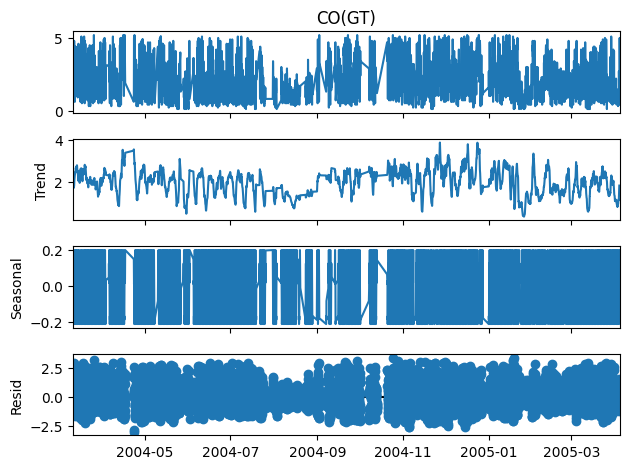

In [24]:
# seasonal decompossition graph for CO
season_no2 = seasonal_decompose(df_dt['CO(GT)'], model='additive', period=24)
season_no2.plot()
plt.show()

Correlation Analysis

In [25]:
# correlation analysis with respect to CO 
def corr_analysis(col_name):
    corr_of_co = df_dt.corr()[col_name].sort_values(ascending=False)
    return pd.DataFrame(corr_of_co)

corr_analysis('CO(GT)')

,CO(GT)
CO(GT),1.000000
PT08.S2(NMHC),0.884637
C6H6(GT),0.882226
PT08.S1(CO),0.836814
PT08.S5(O3),0.812020
NOx(GT),0.741803
NO2(GT),0.686620
PT08.S4(NO2),0.581368
NMHC(GT),0.264553
T,0.086478


In [26]:
# correlation analysis with respect to NO2
corr_analysis('NO2(GT)')

,NO2(GT)
NO2(GT),1.000000
NOx(GT),0.740109
CO(GT),0.686620
PT08.S5(O3),0.671809
PT08.S2(NMHC),0.617432
PT08.S1(CO),0.616779
C6H6(GT),0.583448
NMHC(GT),0.182468
PT08.S4(NO2),0.103580
RH,-0.141671



### 3. Feature Engineering
- Create lag features for `CO(GT)` and `NO₂(GT)` to incorporate historical values.
- Add time-based features (e.g., hour of the day, day of the week, month).
- Include environmental factors (`T`, `RH`, `AH`) as predictors.


Autocorrelation Plots (ACF)

In [27]:
# ACF Plot 
def acf_plot(col_name):
    plot_acf(df_dt[col_name].dropna(), lags=40)
    return plt.show()


CO(GT) ACF Plot : 


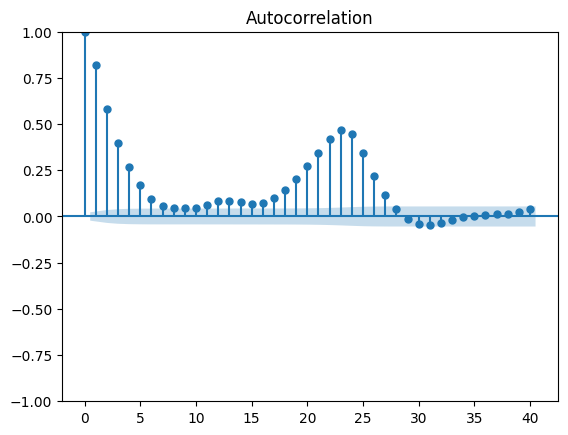

NO2(GT) ACF Plot : 


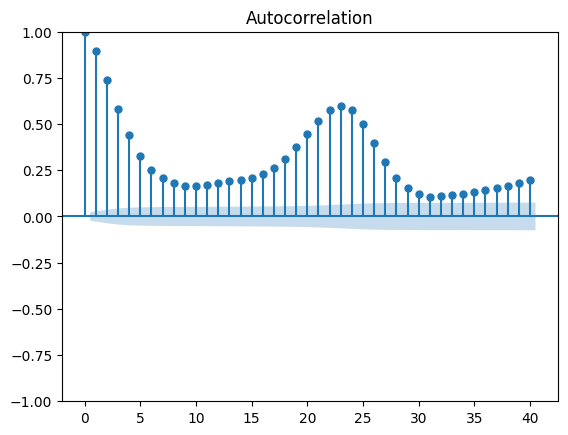

In [28]:
# acf plots for CO and NO2
print('CO(GT) ACF Plot : ')
acf_plot('CO(GT)')

print('NO2(GT) ACF Plot : ')
acf_plot('NO2(GT)')

Partial Autocorrelation Plot (PACF)

In [29]:
def pacf_plot(col_name):
    plot_pacf(df_dt[col_name].dropna(), lags=40)
    return plt.show()

CO(GT) PACF Plot : 


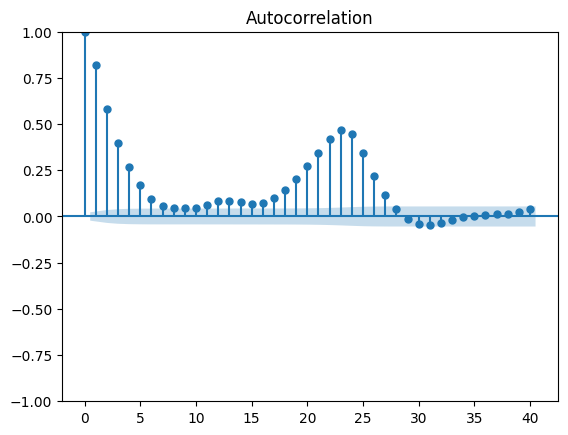

NO2(GT) PACF Plot : 


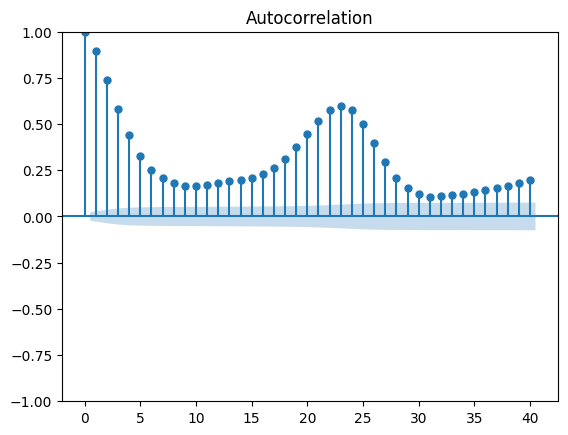

In [30]:
# pacf plots for CO and NO2

print('CO(GT) PACF Plot : ')
acf_plot('CO(GT)')

print('NO2(GT) PACF Plot : ')
acf_plot('NO2(GT)')

In [31]:
# function of lag features
def lag_feature(lag_name, col_name, lag_shift):
    df_dt[lag_name] = df_dt[col_name].shift(lag_shift)


In [32]:
# add lag features in CO 
lag_feature('CO_lag_1', 'CO(GT)', 1)
lag_feature('CO_lag_2', 'CO(GT)', 2)
lag_feature('CO_lag_3', 'CO(GT)', 3)
lag_feature('CO_lag_24', 'CO(GT)', 24)

# add lag features in NO2
lag_feature('NO2_lag_1', 'NO2(GT)', 1)
lag_feature('NO2_lag_2', 'NO2(GT)', 2)
lag_feature('NO2_lag_3', 'NO2(GT)', 3)
lag_feature('NO2_lag_24', 'NO2(GT)', 24)

df_dt = df_dt.dropna()
df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),...,RH,AH,CO_lag_1,CO_lag_2,CO_lag_3,CO_lag_24,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_24
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-11 18:00:00,4.8,1581.0,307.0,20.8,1319.0,281.0,799.0,151.0,2083.0,1409.0,...,64.2,0.8065,2.9,2.2,2.2,2.6,135.0,131.0,126.0,113.0
2004-03-11 21:00:00,3.9,1313.0,197.0,12.8,1076.0,240.0,957.0,136.0,1707.0,1285.0,...,64.0,0.7419,4.8,2.9,2.2,2.0,151.0,135.0,131.0,92.0
2004-03-11 22:00:00,1.5,965.0,61.0,4.7,749.0,94.0,1325.0,85.0,1333.0,821.0,...,63.4,0.6905,3.9,4.8,2.9,2.2,136.0,151.0,135.0,114.0
2004-03-11 23:00:00,1.0,913.0,26.0,2.6,629.0,47.0,1565.0,53.0,1252.0,552.0,...,60.8,0.6657,1.5,3.9,4.8,2.2,85.0,136.0,151.0,122.0
2004-03-12 00:00:00,1.7,1080.0,55.0,5.9,805.0,122.0,1254.0,97.0,1375.0,816.0,...,58.5,0.6438,1.0,1.5,3.9,1.6,53.0,85.0,136.0,116.0


In [33]:
# time based features
df_dt['hour'] = df_dt.index.hour
df_dt['day_of_week'] = df_dt.index.dayofweek
df_dt['month'] = df_dt.index.month

df_dt.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),...,CO_lag_2,CO_lag_3,CO_lag_24,NO2_lag_1,NO2_lag_2,NO2_lag_3,NO2_lag_24,hour,day_of_week,month
datetime,,,,,,,,,,,,,,,,,,,,,
2004-03-11 18:00:00,4.8,1581.0,307.0,20.8,1319.0,281.0,799.0,151.0,2083.0,1409.0,...,2.2,2.2,2.6,135.0,131.0,126.0,113.0,18,3,3
2004-03-11 21:00:00,3.9,1313.0,197.0,12.8,1076.0,240.0,957.0,136.0,1707.0,1285.0,...,2.9,2.2,2.0,151.0,135.0,131.0,92.0,21,3,3
2004-03-11 22:00:00,1.5,965.0,61.0,4.7,749.0,94.0,1325.0,85.0,1333.0,821.0,...,4.8,2.9,2.2,136.0,151.0,135.0,114.0,22,3,3
2004-03-11 23:00:00,1.0,913.0,26.0,2.6,629.0,47.0,1565.0,53.0,1252.0,552.0,...,3.9,4.8,2.2,85.0,136.0,151.0,122.0,23,3,3
2004-03-12 00:00:00,1.7,1080.0,55.0,5.9,805.0,122.0,1254.0,97.0,1375.0,816.0,...,1.5,3.9,1.6,53.0,85.0,136.0,116.0,0,4,3


In [34]:
df_dt.to_csv('dataset_clean.csv')

In [35]:
# feature selection for X and Y split for CO(GT) with external features
X_of_co_ext = df_dt[['T', 'RH', 'AH', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'CO_lag_24', 'hour', 'day_of_week', 'month']]
y_of_co_ext = df_dt['CO(GT)']

X_of_no2_ext = df_dt[['T', 'RH', 'AH', 'NO2_lag_1', 'NO2_lag_2', 'NO2_lag_3', 'NO2_lag_24', 'hour', 'day_of_week', 'month']]
y_of_no2_ext = df_dt['NO2(GT)']


In [36]:
# feature selection for X and Y split for CO(GT) without external features
y_of_co_uni = df_dt['CO(GT)']
y_of_no2_uni = df_dt['NO2(GT)']

In [37]:
class UniTrainTestSplit:
    def uniSize(self, dfs):
        uni_train_size = len(dfs) - 120
        uni_train = dfs.iloc[:uni_train_size]
        uni_test = dfs.iloc[uni_train_size:]
        frame = {
            'uni_train_s': uni_train,
            'uni_test_s': uni_test
        }
        return frame

### 4. Time-Series Forecasting
- Train separate models for **CO(GT)** and **NO₂(GT)**.
- Explore the following forecasting approaches:
  - **Statistical Models**:
    - Classical models like ARIMA or SARIMA for univariate forecasting.
  - **Machine Learning Models**:
    - Use regression models trained on lag features and external predictors.
  - **Deep Learning Models**:
    - Apply LSTM, GRU, or other RNN-based models for sequence forecasting.
- Evaluate and compare the models.


Seasonal Auto Regressive Moving Average (SARIMA)

In [38]:
# Augmented Dickey-Fuller Test (p Value measurment)
def adf_test(col_name):
    result = adfuller(df_dt[col_name].dropna())
    if result[1] <= 0.05:
        print(f'{col_name} is Stationary with p Value = {result}')
    else:
        print(f'{col_name} is Non-Stationary with p Value = {result}')

adf_test('CO(GT)')
adf_test('NO2(GT)')


CO(GT) is Stationary with p Value = (np.float64(-10.070311545437319), np.float64(1.2640721693416274e-17), 34, 7386, {'1%': np.float64(-3.431235672100475), '5%': np.float64(-2.861931399130876), '10%': np.float64(-2.5669783374375994)}, np.float64(13601.587001663682))
NO2(GT) is Stationary with p Value = (np.float64(-7.083941377123859), np.float64(4.589964955290744e-10), 26, 7394, {'1%': np.float64(-3.43123471350717), '5%': np.float64(-2.861930975569223), '10%': np.float64(-2.566978111969519)}, np.float64(63258.78331069542))


In [39]:
# seasonal p from ACF 
def seasonal_acf(col_name):
    acf_val = acf(df_dt[col_name], nlags=24)
    return acf_val[24]

# seasonal q from PACF
def seasonal_pacf(col_name):
    pacf_val = pacf(df_dt[col_name], nlags=24)
    return pacf_val[24]

print(f'seasonal P of CO(GT) in 24 Lag (acf): {seasonal_acf('CO(GT)')}')
print(f'seasonal P of NO2(GT) in 24 Lag (acf): {seasonal_acf('NO2(GT)')}')

print(f'seasonal q of CO(GT) in 24 Lag (pacf): {seasonal_pacf('CO(GT)')}')
print(f'seasonal q of NO2(GT) in 24 Lag (pacf): {seasonal_pacf('NO2(GT)')}')


seasonal P of CO(GT) in 24 Lag (acf): 0.445164258138221
seasonal P of NO2(GT) in 24 Lag (acf): 0.5744660823487325
seasonal q of CO(GT) in 24 Lag (pacf): -0.04846892110493313
seasonal q of NO2(GT) in 24 Lag (pacf): -0.06659075882607976


In [40]:
# seasonal d (diffrencing)
def seasonal_diff(col_name):
    seasonal_diff_val = df_dt[col_name].diff(24).dropna()
    result = adfuller(seasonal_diff_val)
    return result[1]

print(f'seasonal p-Value of CO(GT): {seasonal_diff('CO(GT)')}')
print(f'seasonal p-Value of NO2(GT): {seasonal_diff('NO2(GT)')}')


seasonal p-Value of CO(GT): 3.979860588404527e-30
seasonal p-Value of NO2(GT): 4.355732821082157e-30


In [41]:
# Manual paramerter selection for SARIMA
# defination of p, d, q for CO(GT) - order
p_order_co = 1 # based on pacf plot of CO(GT)
d_order_co = 0 # stationaty and p_value is <= 0.05
q_order_co = 1 # based on acf plot of CO(GT)

# defination of p, d, q for NO2(GT) - order
p_order_co = 1 # based on pacf plot of NO2(GT)
d_order_co = 0 # stationaty and p_value is <= 0.05
q_order_co = 1 # based on acf plot of NO2(GT)

# defination of p, d, q for CO(GT) - seasonal
s_season = 24 
d_season_co = 0 
q_season_co = 0 
p_season_co = 1

# defination of p, d, q for NO2(GT) - seasonal
s_season = 24 
d_season_no2 = 0 
q_season_no2 = 1 
p_season_no2 = 1

In [75]:
# function of evaluting the sarima parameters through auto arima model 
obj = UniTrainTestSplit()
y_train_uni_co = obj.uniSize(y_of_co_uni)['uni_train_s']

def auto_arima_params(col_name):
    model = pm.auto_arima(col_name, 
                          stepwise=True, 
                          trace=True, 
                          seasonal=True, 
                          max_p=2, 
                          max_q=2,
                          max_P=1,
                          max_Q=1,
                          m=24)
    return model.summary()

# model.plot_diagnostics(figsize=(12, 8))

# summary of CO(GT)
auto_arima_params(y_train_uni_co.iloc[-1000:])

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=1813.900, Time=11.17 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=2895.146, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=1925.372, Time=2.25 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=2082.953, Time=1.15 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=4249.651, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=1809.480, Time=9.17 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=1815.153, Time=0.79 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=1809.694, Time=5.09 sec
 ARIMA(1,0,2)(0,0,1)[24] intercept   : AIC=1808.506, Time=2.57 sec
 ARIMA(1,0,2)(0,0,0)[24] intercept   : AIC=1814.016, Time=0.50 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=1810.481, Time=7.35 sec
 ARIMA(1,0,2)(1,0,0)[24] intercept   : AIC=1808.716, Time=3.67 sec
 ARIMA(0,0,2)(0,0,1)[24] intercept   : AIC=1866.075, Time=1.94 sec
 ARIMA(1,0,1)(0,0,1)[24] intercept   : AIC=1813.307, Time=2.18 sec
 ARIMA(2,0,1)(0,0,

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                 1000
Model:             SARIMAX(1, 0, 2)x(0, 0, [1], 24)   Log Likelihood                -898.253
Date:                              Tue, 07 Apr 2026   AIC                           1808.506
Time:                                      03:01:28   BIC                           1837.953
Sample:                                           0   HQIC                          1819.698
                                             - 1000                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.8156      0.121      6.761      0.000       0.579       1.052
ar.L1          0.5325      0.057      9.421      0.000       0.422       0.643
ma.L1          0.5277      0.058      9.136      0.000       0.414       0.641
ma.L2          0.1402      0.053      2.630      0.009       0.036       0.245
ma.S.L24       0.0931      0.033      2.815      0.005       0.028       0.158
sigma2         0.3525      0.013     27.184      0.000       0.327       0.378
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               425.48
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.74   Skew:                             0.84
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [76]:
# arima summary of NO2(GT)
y_train_uni_no2 = obj.uniSize(y_of_no2_uni)['uni_train_s']
auto_arima_params(y_train_uni_no2.iloc[-1000:])

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=8.44 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=9168.707, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=9079.304, Time=1.32 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=9069.206, Time=1.28 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=9166.721, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[24] intercept   : AIC=9083.843, Time=0.42 sec
 ARIMA(0,1,1)(1,0,1)[24] intercept   : AIC=9071.082, Time=2.28 sec
 ARIMA(0,1,1)(1,0,0)[24] intercept   : AIC=9070.142, Time=1.85 sec
 ARIMA(0,1,0)(0,0,1)[24] intercept   : AIC=9134.579, Time=1.02 sec
 ARIMA(1,1,1)(0,0,1)[24] intercept   : AIC=9070.652, Time=3.10 sec
 ARIMA(0,1,2)(0,0,1)[24] intercept   : AIC=9070.519, Time=2.95 sec
 ARIMA(1,1,0)(0,0,1)[24] intercept   : AIC=9078.379, Time=1.52 sec
 ARIMA(1,1,2)(0,0,1)[24] intercept   : AIC=inf, Time=7.05 sec
 ARIMA(0,1,1)(0,0,1)[24]             : AIC=9067.212, Time=0.62 sec
 ARIMA(0,1,1)(0,0,0)[24]     

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                 1000
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 24)   Log Likelihood               -4530.606
Date:                            Tue, 07 Apr 2026   AIC                           9067.212
Time:                                    03:03:20   BIC                           9081.932
Sample:                                         0   HQIC                          9072.807
                                           - 1000                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2776      0.026     10.550      0.000       0.226       0.329
ma.S.L24       0.1348      0.027      4.935      0.000       0.081       0.188
sigma2       508.7110     16.987     29.947      0.000     475.417     542.005
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):               115.02
Prob(Q):                              0.84   Prob(JB):                         0.00
Heteroskedasticity (H):               0.50   Skew:                            -0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [44]:
# SARIMA Model training 
class ModelSARIMA:
    def model_sarima(self, y, p, d, q, P, D, Q, S):
         return SARIMAX(y, 
                        order=(p, d, q), 
                        seasonal_order=(P, D, Q, S),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

In [90]:
obj = UniTrainTestSplit()
y_train_uni_co = obj.uniSize(y_of_co_uni)['uni_train_s']

obj_co_sarima_model = ModelSARIMA()
co_result = obj_co_sarima_model.model_sarima(y_train_uni_co,
                                        1, 0, 1, 
                                        1, 0, 0, 24).fit(disp=False)

print(co_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              CO(GT)   No. Observations:                 7301
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 24)   Log Likelihood               -7291.353
Date:                             Tue, 07 Apr 2026   AIC                          14590.706
Time:                                     03:07:31   BIC                          14618.275
Sample:                                          0   HQIC                         14600.187
                                            - 7301                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9033      0.005    191.922      0.000       0.894       0.913
ma.L1          0.2145      

In [ ]:
obj = UniTrainTestSplit()
y_train_uni_no2 = obj.uniSize(y_of_no2_uni)['uni_train_s']

obj_no2_sarima_model = ModelSARIMA()
no2_result = obj_no2_sarima_model.model_sarima(y_train_uni_no2,
                                               0, 1, 1, 
                                               1, 0, 1, 24).fit(disp=False)
print(no2_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            NO2(GT)   No. Observations:                 7301
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 24)   Log Likelihood              -31815.374
Date:                            Tue, 07 Apr 2026   AIC                          63636.749
Time:                                    03:04:39   BIC                          63657.425
Sample:                                         0   HQIC                         63643.860
                                           - 7301                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1989      0.009     22.242      0.000       0.181       0.216
ma.S.L24       0.1666      0.010   

SARIMA Forecasting

In [79]:
class TimeSeriesForecaster:
    def __init__(self):
        self.results = {} 
        
    def run_forecast(self, yTest, model_result, name):
        tag_forecast = model_result.get_forecast(steps=len(yTest))
        
        self.results[name] = {
            'y_forecast': tag_forecast.predicted_mean,
            'conf_interval': tag_forecast.conf_int(),
            'forecast_df': pd.DataFrame({
                'Actual': yTest.values, 
                'Forecast': tag_forecast.predicted_mean.values
            }, index=yTest.index)
        }

        return self.results[name]['forecast_df']

In [80]:
test_no2 = obj.uniSize(y_of_no2_uni)['uni_test_s']

forecasting = TimeSeriesForecaster()
df_forecast_no2 = forecasting.run_forecast(test_no2, no2_result, 'NO2')
df_forecast_no2.head(20)

,Actual,Forecast
datetime,,
2005-03-30 15:00:00,125.0,125.541706
2005-03-30 16:00:00,135.0,125.352268
2005-03-30 17:00:00,179.0,125.469324
2005-03-30 18:00:00,183.0,128.637912
2005-03-30 19:00:00,193.0,122.944444
2005-03-30 20:00:00,185.0,124.801428
2005-03-30 21:00:00,147.0,124.158584
2005-03-30 22:00:00,117.0,120.439807
2005-03-30 23:00:00,112.0,117.300172


In [81]:
test_co = obj.uniSize(y_of_co_uni)['uni_test_s']
df_forecast_co = forecasting.run_forecast(test_co, co_result, 'CO')
df_forecast_co.head(20)

,Actual,Forecast
datetime,,
2005-03-30 15:00:00,1.8,1.828091
2005-03-30 16:00:00,1.7,1.721710
2005-03-30 17:00:00,3.2,1.755120
2005-03-30 18:00:00,3.4,1.751885
2005-03-30 19:00:00,4.2,1.394253
2005-03-30 20:00:00,3.5,1.481418
2005-03-30 21:00:00,2.0,1.284192
2005-03-30 22:00:00,1.4,1.056642
2005-03-30 23:00:00,1.5,0.942689


In [82]:
def forecast_plot(yTest, df_forecast, conf_int, col_name):
    plt.figure(figsize=(12, 6))
    
    y_true = yTest.iloc[:120]
    y_pred = df_forecast.iloc[:120]
    ci = conf_int.iloc[:120]

    plt.plot(y_true.index, y_true.values, label='Actual', color='blue', alpha=0.6)
    plt.plot(y_true.index, y_pred.values, label='Forecast', color='red', linestyle='--')

    plt.fill_between(y_true.index, 
                     ci.iloc[:, 0], 
                     ci.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

    plt.title(f'{col_name} SARIMA Forecasting Results')
    plt.xlabel('Date/Time')
    plt.ylabel('Concentration')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [83]:
co_confidence_interval = forecasting.results['CO']['conf_interval']
no2_confidence_interval = forecasting.results['NO2']['conf_interval']

In [84]:
co_confidence_interval.head()

,lower CO(GT),upper CO(GT)
7301,0.536743,3.119439
7302,-0.190272,3.633692
7303,-0.483779,3.994019
7304,-0.738548,4.242318
7305,-1.297418,4.085923


In [85]:
no2_confidence_interval.head()

,lower NO2(GT),upper NO2(GT)
7301,87.913279,163.170133
7302,66.607650,184.096886
7303,51.402046,199.536602
7304,41.914252,215.361573
7305,25.189522,220.699366


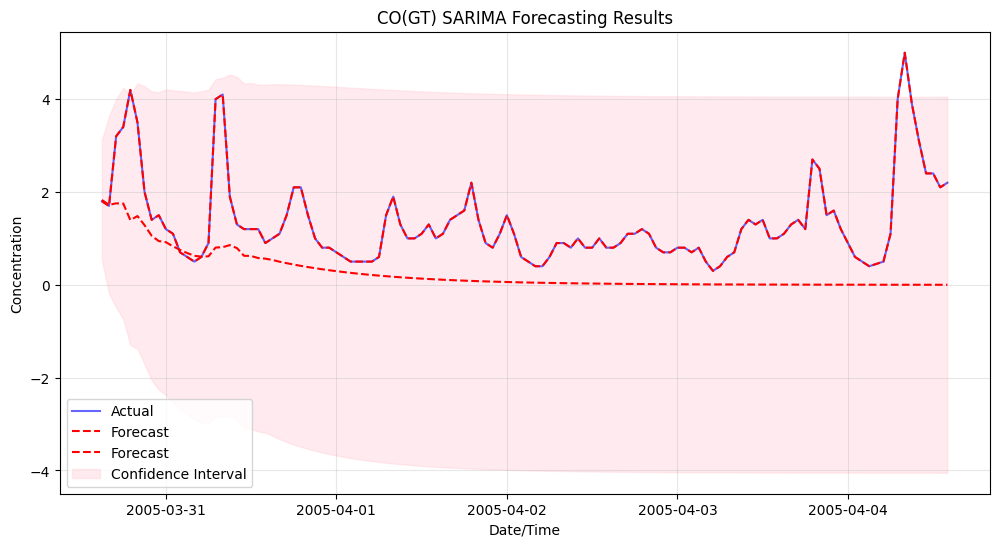

In [86]:
# forecast plot for CO
forecast_plot(test_co, 
              df_forecast_co,
              co_confidence_interval,
              'CO(GT)')

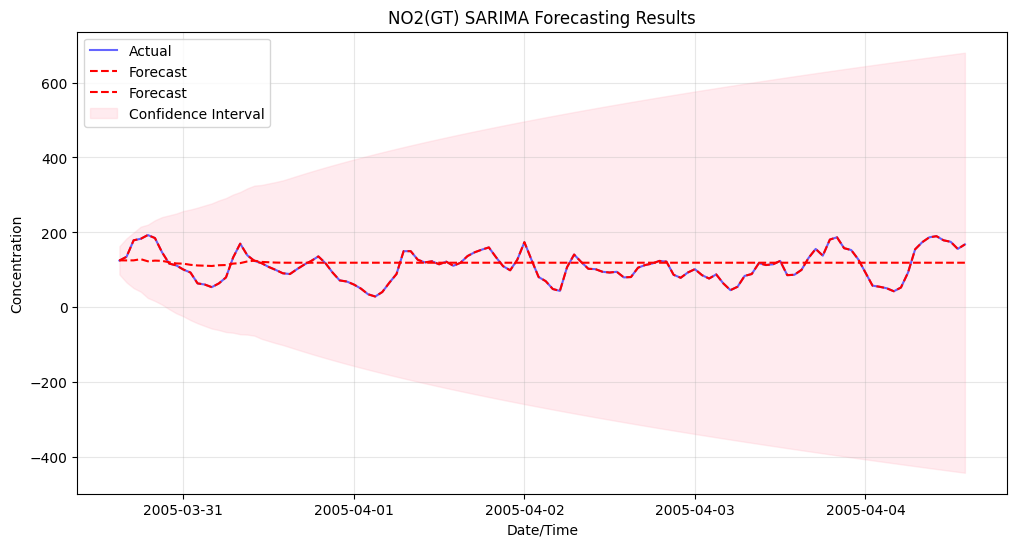

In [87]:
# forecast plot fot NO2
forecast_plot(test_no2, 
              df_forecast_no2,
              no2_confidence_interval,
              'NO2(GT)')

### 5. Model Evaluation
- Use appropriate metrics for forecasting:
  - Mean Absolute Error (MAE)
  - Root Mean Squared Error (RMSE)
  - Mean Absolute Percentage Error (MAPE)
- Plot actual vs. predicted values to visualize performance.


In [88]:
# Evaluation
class Eval:
    def eval(self, df_name, col_name):
        mean_ = df_name['Actual'].mean()
        r_square = r2_score(df_name['Actual'], df_name['Forecast'])
        rmse_ = np.sqrt(mean_squared_error(df_name['Actual'], df_name['Forecast']))
        mae_ = mean_absolute_error(df_name['Actual'], df_name['Forecast'])
        mape_ = (rmse_ / mean_) * 100

        eval_results = {
            "feature_name" : col_name,
            "feature_mean" : mean_,
            "feature_rmse" : rmse_,
            "feature_mae" : mae_,
            "feature_mape" : mape_,
            "feature_r_square" : r_square
        }

        return eval_results

In [89]:
obj_eval = Eval()
# result = obj_eval.eval(df_forecast_co, 'CO')
# result['feature_name']
result_sarima_co = obj_eval.eval(df_forecast_co, 'CO')
result_sarima_no2 = obj_eval.eval(df_forecast_no2, 'NO2')

data = {
    'Mean': [result_sarima_co['feature_mean'], result_sarima_no2['feature_mean']],
    'R Square': [result_sarima_co['feature_r_square'], result_sarima_no2['feature_r_square']],
    'RMSE': [result_sarima_co['feature_rmse'], result_sarima_no2['feature_rmse']],
    'MAE': [result_sarima_co['feature_mae'], result_sarima_no2['feature_mae']],
    'MAPE (%)': [result_sarima_co['feature_mape'], result_sarima_no2['feature_mape']]
}

performance_df = pd.DataFrame(data, index=[result_sarima_co['feature_name'], 
                                           result_sarima_no2['feature_name']
                                           ])

print('SARIMA Model performance evaluation for CO(GT) and NO2(GT)')
performance_df

SARIMA Model performance evaluation for CO(GT) and NO2(GT)


,Mean,R Square,RMSE,MAE,MAPE (%)
CO,1.328750,-1.214795,1.365553,1.065518,102.769708
NO2,110.583333,-0.006669,39.650878,32.091717,35.856107


### 6. Visualization and Insights
- Generate forecasts for future dates and visualize the trends.
- Highlight seasonal patterns, peak times, and periods of concern.
- Provide actionable recommendations based on predicted trends.

